# Limpieza y Análisis de Datos con Vino

Este notebook trabaja con el archivo `data\winemag-data-130k-v2.csv`.

Objetivos:
1. Impotación de librerias
2. Cargar datos y explorarlos.
3. Verificar tipos de datos
4. Limpieza y prepación de datos
5. Verificar valores nulos
6. Normalizar/Limpiar columnas
7. Crear columnas derivadas
8. Estadisticas globales
9. Análisis por país o provincia
10. Variedad de uva (variety)
11. Relación entre precio y puntuación
12. Análisis de longitud de reseña
13. Uno de NumPy para analisis
14. Hacer un mini análisis final.

## 1. Impotación de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar de datos y exploración.

In [2]:

# Cargar el CSV (si lo tienes guardado como 'wines.csv')
df = pd.read_csv("data/winemag-data-130k-v2.csv")

# Mostrar primeras filas
print(df.head())

# Ver información general
print(df.info())


   id   country                                        description  \
0   0     Italy  Aromas include tropical fruit, broom, brimston...   
1   1  Portugal  This is ripe and fruity, a wine that is smooth...   
2   2        US  Tart and snappy, the flavors of lime flesh and...   
3   3        US  Pineapple rind, lemon pith and orange blossom ...   
4   4        US  Much like the regular bottling from 2012, this...   

                          designation  points  price           province  \
0                        Vulkà Bianco      87    NaN  Sicily & Sardinia   
1                            Avidagos      87   15.0              Douro   
2                                 NaN      87   14.0             Oregon   
3                Reserve Late Harvest      87   13.0           Michigan   
4  Vintner's Reserve Wild Child Block      87   65.0             Oregon   

              region_1           region_2         taster_name  \
0                 Etna                NaN       Kerin O’Keefe  

## 3.Verificar tipos de datos

In [3]:

print("Tipos de datos (antes) de las columnas:")
print(df.dtypes)

Tipos de datos (antes) de las columnas:
id                         int64
country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object


## 4. Limpieza y preparación de datos

In [4]:

# Convertir y asegurar que las  columnas numéricas puedan venir como texto
df['id'] = pd.to_numeric(df['id'], errors='coerce').astype('Int64')
df['price'] = pd.to_numeric(df['price'], errors='coerce').astype(float)
df['points'] = pd.to_numeric(df['points'], errors='coerce').astype('Int64')

# Puede tener mezcla de enteros y strings -> forzamos conversión segura
df = df.astype({col: "string" for col in df.select_dtypes(include="object").columns})

print("TIPOS DESPUÉS:")
print(df.dtypes)

display(df.head())

TIPOS DESPUÉS:
id                                Int64
country                  string[python]
description              string[python]
designation              string[python]
points                            Int64
price                           float64
province                 string[python]
region_1                 string[python]
region_2                 string[python]
taster_name              string[python]
taster_twitter_handle    string[python]
title                    string[python]
variety                  string[python]
winery                   string[python]
dtype: object


,id,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,<NA>,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,<NA>,<NA>,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",<NA>,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,<NA>,Alexander Peartree,<NA>,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## 5. Verificar valores nulos

In [5]:
print("Valores nulos por columna:")
#Conteo valores nulos
print(df.isna().sum())

Valores nulos por columna:
id                           0
country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


## 6.Normalizar/Limpiar columnas 

In [6]:

#Eliminar Nan de paises
df['country'] = df['country'].fillna("Desconocido")

# Capitalizar paises
df['country'] = df['country'].astype(str).str.capitalize()

# Quitar espacios en variety
df['variety'] = (
    df['variety']
        .astype(str)
        .str.strip()
        .str.title()
        .str.replace(' ', '', regex=False)
)

print("Capitalizar paises: ")

print(df['country'].head())

print("Quitar espacios variety: ")

print(df['variety'].head())


##Limpieza de columnas duplicadas
duplicados = df[df.duplicated()]

print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

print(df.head)


Capitalizar paises: 
0       Italy
1    Portugal
2          Us
3          Us
4          Us
Name: country, dtype: object
Quitar espacios variety: 
0       WhiteBlend
1    PortugueseRed
2        PinotGris
3         Riesling
4        PinotNoir
Name: variety, dtype: object
Filas duplicadas detectadas:


,id,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery


Tamaño tras eliminar duplicados: (129971, 14)
<bound method NDFrame.head of             id   country                                        description  \
0            0     Italy  Aromas include tropical fruit, broom, brimston...   
1            1  Portugal  This is ripe and fruity, a wine that is smooth...   
2            2        Us  Tart and snappy, the flavors of lime flesh and...   
3            3        Us  Pineapple rind, lemon pith and orange blossom ...   
4            4        Us  Much like the regular bottling from 2012, this...   
...        ...       ...                                                ...   
129966  129966   Germany  Notes of honeysuckle and cantaloupe sweeten th...   
129967  129967        Us  Citation is given as much as a decade of bottl...   
129968  129968    France  Well-drained gravel soil gives this wine its c...   
129969  129969    France  A dry style of Pinot Gris, this is crisp with ...   
129970  129970    France  Big, rich and off-dry, this i

## 7. Crear columnas derivadas

In [7]:
# booleano si el vino tiene precio registrado)
df['has_price'] = df['price'].notnull()

print("Tiene precio registrado?:")

print(df['has_price'].head())

# Combinación de regiones
df['region_combined'] = df['region_1'].fillna('') + ' | ' + df['region_2'].fillna('')


print("Combinación de regiones:")

print(df['region_combined'].head())


# longitud del texto de descripcion
df['review_lenght'] = df['description'].str.len()


print("Longitud del texto descriptivo:")

print(df['review_lenght'].head())

Tiene precio registrado?:
0    False
1     True
2     True
3     True
4     True
Name: has_price, dtype: bool
Combinación de regiones:
0                                  Etna | 
1                                       | 
2    Willamette Valley | Willamette Valley
3                   Lake Michigan Shore | 
4    Willamette Valley | Willamette Valley
Name: region_combined, dtype: string
Longitud del texto descriptivo:
0    172
1    227
2    186
3    199
4    249
Name: review_lenght, dtype: Int64


## 8. Estadisticas globales

In [8]:
#Calcular la media, mediana, desviación estándar, mínimo/máximo de variables numéricas: points, price, review_length.
print("--POINTS--")
media = df['points'].mean()
print("La media de puntos:" , media)
mediana = df['points'].median()
print("La mediana de puntos: " ,  mediana)
max = df['points'].max()
print("El máximo de puntos: " ,  max)
min = df['points'].min()
print("El mínimo de puntos: " ,  min)
des = df['points'].std()
print("La desviación estándar de puntos: " ,  des)


print("--PRICE--")
df_filtrado = df[df['has_price'] == True]['price']
media = df_filtrado.mean()
print("La media de precios:" , media)
mediana = df_filtrado.median()
print("La mediana de precios: " ,  mediana)
max = df_filtrado.max()
print("El máximo de precios: " ,  max)
min = df_filtrado.min()
print("El mínimo de precios: " ,  min)
des = df_filtrado.std()
print("La desviación estándar de precios: " ,  des)

print("--REVIEW LENGTH--")

media = df['review_lenght'].mean()
print("La media de reseñas:", media)
mediana = df['review_lenght'].median()
print("La mediana de reseñas: " ,  mediana)
max = df['review_lenght'].max()
print("El máximo de reseñas: " ,  max)
min = df['review_lenght'].min()
print("El mínimo de reseñas: " ,  min)
des = df['review_lenght'].std()
print("La desviación estándar de precios: " ,  des)

print("------------------------------------------------------")
print("--ESTADÍSTICAS BÁSICAS--")
registros = len(df)
print("Cantidad registros:", registros)

print("--PAISES DISTINTOS--")
cantidad_p = df['country'].nunique()
print("Paises distintos:" , cantidad_p)

print("--BODEGAS DISTINTAS--")
cantidad_w = df['winery'].nunique()
print("Bodegas distintas:" , cantidad_w)


--POINTS--
La media de puntos: 88.44713820775404
La mediana de puntos:  88.0
El máximo de puntos:  100
El mínimo de puntos:  80
La desviación estándar de puntos:  3.0397302029160036
--PRICE--
La media de precios: 35.363389129985535
La mediana de precios:  25.0
El máximo de precios:  3300.0
El mínimo de precios:  4.0
La desviación estándar de precios:  41.02221766808723
--REVIEW LENGTH--
La media de reseñas: 242.60106485292874
La mediana de reseñas:  237.0
El máximo de reseñas:  829
El mínimo de reseñas:  20
La desviación estándar de precios:  66.58427575902327
------------------------------------------------------
--ESTADÍSTICAS BÁSICAS--
Cantidad registros: 129971
--PAISES DISTINTOS--
Paises distintos: 44
--BODEGAS DISTINTAS--
Bodegas distintas: 16757


## 9. Análisis por país o provincia


In [9]:

# Agrupar por country (o province) para calcular:
paises = df.groupby("country")

# número de vinos registrados
vinos_registrados = paises.size()   # cuenta filas por país
print("\n------VINOS REGISTRADOS------")
print("\nVinos registrados por país:" , vinos_registrados)

# precio medio (has_price) 
# Utilizamos el has_price porque quitamos los nulos en el apartado 7
mediana_paises = paises["price"].median()
print("\n------MEDIANA DE PRECIOS POR PAISES------")
print("\nEl precio medio por país es: " ,  mediana_paises)

# puntuación media (points)
mediana_points = paises["points"].median()
print("\n------MEDIANA DE PUNTOS POR PAISES-------")
print("\nLos puntos medio por país es: " ,  mediana_points)

# Ordenar países de mayor a menor según puntuación media o precio medio.
print("\n---- PAISES ORDENADOS POR PRECIO (mayor → menor) ----")
paises = mediana_paises.sort_values(ascending = False)
print(paises)
print("\n----PAISES SEGÚN LOS PUNTOS (mayor → menor)----")
paises = mediana_points.sort_values(ascending = False)
print(paises)

# Reflexionar: ¿qué países destacan en precio vs. puntuación?
division= mediana_points/mediana_paises
descatados = division.sort_values(ascending = False)
print("\n----PAISES CON MAYOR CANTIDAD DE PRECIOS Y PUNTOS-----")
print(descatados)




------VINOS REGISTRADOS------

Vinos registrados por país: country
Argentina                  3800
Armenia                       2
Australia                  2329
Austria                    3345
Bosnia and herzegovina        2
Brazil                       52
Bulgaria                    141
Canada                      257
Chile                      4472
China                         1
Croatia                      73
Cyprus                       11
Czech republic               12
Desconocido                  63
Egypt                         1
England                      74
France                    22093
Georgia                      86
Germany                    2165
Greece                      466
Hungary                     146
India                         9
Israel                      505
Italy                     19540
Lebanon                      35
Luxembourg                    6
Macedonia                    12
Mexico                       70
Moldova                      59
Moro

## 10. Variedad de uva (variety)



In [10]:
#Agrupar por variety para calcular:
agrupacion_variety =  df.groupby("variety")

#número de vinos
vinos_registrados = agrupacion_variety.size()   # cuenta filas por país
print("\n------VINOS REGISTRADOS------")
print("\nVinos registrados por variación de vinos:" , vinos_registrados)

#puntuación media (points)

mediana_points = agrupacion_variety["points"].median()
print("\n------MEDIANA DE PUNTOS POR PAISES-------")
print("\nLos puntos medio por variación de vinos son: " ,  mediana_points)

#precio medio (price)

mediana_price = agrupacion_variety["price"].median()
print("\n------MEDIANA DE PRECIO POR VARIACIÓN DE VINOS -------")
print("\nEL PRECIO  medio por variación de vinos es: " ,  mediana_price)


#Identificar las variedades con mayor puntuación media, y las que están por debajo del promedio.
print("\n----  ORDENADOS POR PRECIO (mayor → menor) ----")
ordenar_agrupacion_variety = mediana_price.sort_values(ascending = False)
print(ordenar_agrupacion_variety)

print("\n----  PAISES POR DEBAJO DEL PROMEDIO----")
promedio = mediana_points.mean()
paises_debajo_promedio = mediana_points[mediana_points <= promedio]
print(paises_debajo_promedio)




------VINOS REGISTRADOS------

Vinos registrados por variación de vinos: variety
<Na>              1
Abouriou          3
Agiorgitiko      63
Aglianico       359
Aidani            1
               ... 
Zinfandel      2714
Zlahtina          2
Zweigelt        209
Çalkarası         2
Žilavka           1
Length: 708, dtype: int64

------MEDIANA DE PUNTOS POR PAISES-------

Los puntos medio por variación de vinos son:  variety
<Na>           88.0
Abouriou       87.0
Agiorgitiko    87.0
Aglianico      89.0
Aidani         82.0
               ... 
Zinfandel      88.0
Zlahtina       86.0
Zweigelt       89.0
Çalkarası      86.5
Žilavka        88.0
Name: points, Length: 708, dtype: Float64

------MEDIANA DE PRECIO POR VARIACIÓN DE VINOS -------

EL PRECIO  medio por variación de vinos es:  variety
<Na>           17.0
Abouriou       15.0
Agiorgitiko    20.0
Aglianico      33.5
Aidani         27.0
               ... 
Zinfandel      28.0
Zlahtina       14.5
Zweigelt       18.0
Çalkarası      19.0
Ži

## 11. Relación entre precio y puntuación

C:\Users\CassiusTedesco\AppData\Local\Temp\ipykernel_8652\3961806888.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["price_per_point"] = df_filtrado["price"] / df_filtrado["points"]
C:\Users\CassiusTedesco\AppData\Local\Temp\ipykernel_8652\3961806888.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["country_median_price"] = df_filtrado["country"].map(precio_mediano_pais)
C:\Users\CassiusTedesco\AppData\Local\Temp\ipykernel_8652\3961806888.py:14: SettingWithCopyWarning: 
A va


Correlación entre variables:
                          price    points  country_median_price  \
price                  1.000000  0.416167              0.104869   
points                 0.416167  1.000000              0.146177   
country_median_price   0.104869  0.146177              1.000000   
variety_median_points  0.197070  0.288723              0.172740   
winery_median_points   0.377922  0.701976              0.202526   

                       variety_median_points  winery_median_points  
price                               0.197070              0.377922  
points                              0.288723              0.701976  
country_median_price                0.172740              0.202526  
variety_median_points               1.000000              0.307478  
winery_median_points                0.307478              1.000000  


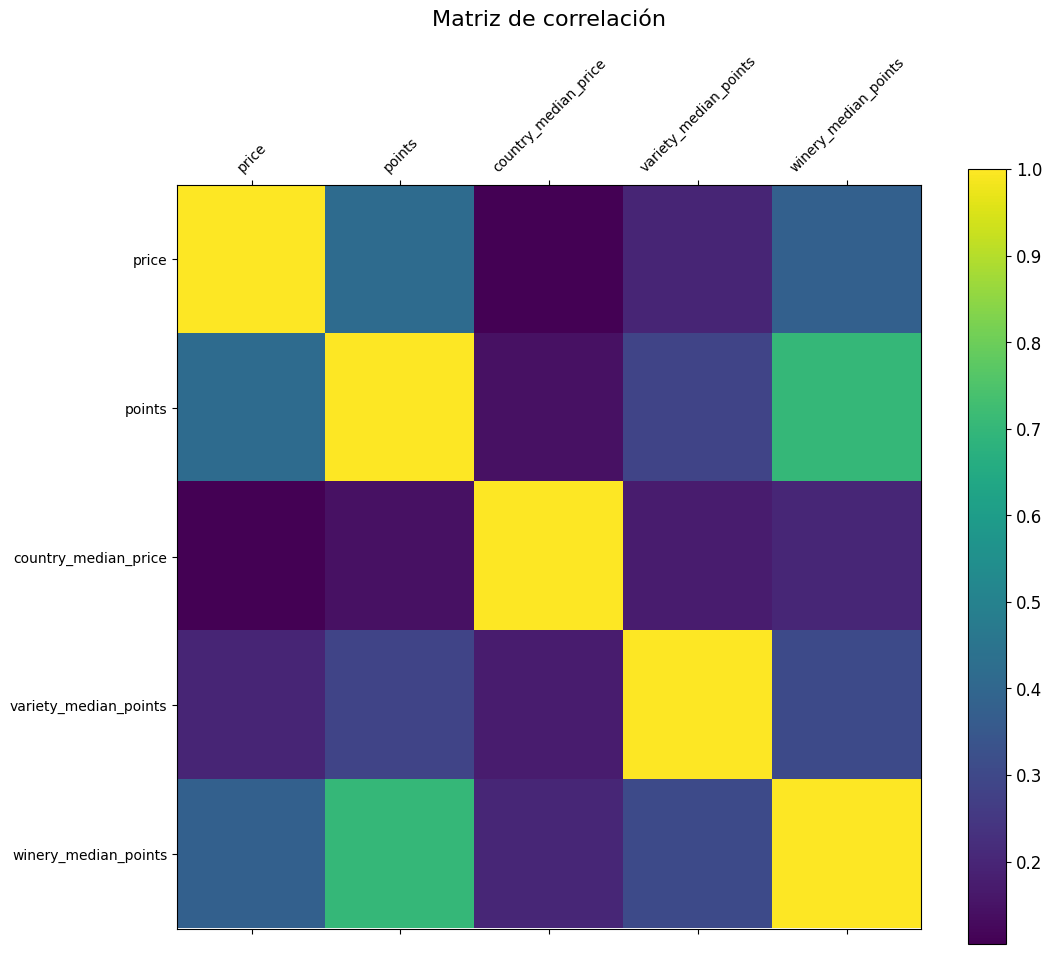

In [11]:
df_filtrado = df[df['has_price'] == True]

#Crear una nueva columna price_per_point = price / points (solo donde price no está nulo) y analizar su distribución.
df_filtrado["price_per_point"] = df_filtrado["price"] / df_filtrado["points"]

# No lo ponemos en la correlación porque era igual que el price

# Precio mediano por país
precio_mediano_pais = df_filtrado.groupby("country")["price"].median()
df_filtrado["country_median_price"] = df_filtrado["country"].map(precio_mediano_pais)

# Puntuacion promedio por variedad de vino
puntos_promedio_variety = df_filtrado.groupby("variety")["points"].median()
df_filtrado["variety_median_points"] = df_filtrado["variety"].map(puntos_promedio_variety)

# Puntuacion promedio bodega
puntos_promedio_bodega = df_filtrado.groupby("winery")["points"].median()
df_filtrado["winery_median_points"] = df_filtrado["winery"].map(puntos_promedio_bodega)

corr_extendida = df_filtrado[
    [
        "price",
        "points",
        "country_median_price",
        "variety_median_points",
        "winery_median_points"
    ]
].corr()

print("\nCorrelación entre variables:")
print(corr_extendida)

#Grafico de la correlacion

fig = plt.figure(figsize=(12, 10))
plt.matshow(corr_extendida, fignum=fig.number, cmap="viridis")

plt.xticks(
    range(len(corr_extendida.columns)),
    corr_extendida.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_extendida.columns)),
    corr_extendida.columns
)

cb = plt.colorbar()
cb.ax.tick_params(labelsize=12)

plt.title("Matriz de correlación", pad=20, fontsize=16)
plt.show()

## 12. Análisis de longitud de reseña

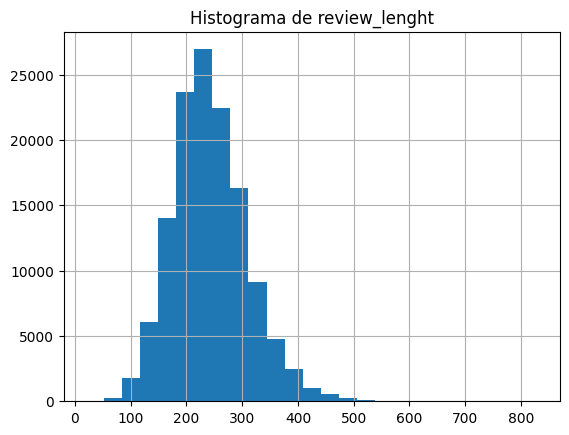

Correlación de review_lenght con precio: 0.25169942188631816
Correlación de review_lenght con points: 0.5577602558815872


In [12]:
# Historigrama de review_lenght

review_lenght = df["review_lenght"]
review_lenght.hist(bins=25)
plt.title(f"Histograma de {review_lenght.name}")
plt.show()

# Correlacion entre review_lenght y precio (no nulos)
df_con_precio = df[df['has_price'] == True].copy()
corr = df_con_precio["review_lenght"].corr(df_con_precio["price"])
print(f"Correlación de review_lenght con precio: {corr}")

# Correlacion de review_lenght y points
corr = df['review_lenght'].corr(df['points'])
print(f"Correlación de review_lenght con points: {corr}")

## 13. Uno de NumPy para analisis

In [13]:
#Usar np.percentile() para calcular percentiles de price, points, price_per_point y detectar valores atípicos.
price_10 = np.percentile(df_filtrado['price'].dropna(), 10)
price_90 = np.percentile(df['price'].dropna(), 90)

points_10 = np.percentile(df_filtrado['points'].dropna(), 10)
points_90 = np.percentile(df['points'], 90)

ppp_10 = np.percentile(df_filtrado['price_per_point'].dropna(), 10)
ppp_90 = np.percentile(df_filtrado['price_per_point'].dropna(), 90)

print("Price: 10% =", price_10, ", 90% =", price_90)
print("Points: 10% =", points_10, ", 90% =", points_90)
print("Price per Point: 10% =", ppp_10, ", 90% =", ppp_90)


#Outliers de precio
outliers_price = df_filtrado[(df_filtrado['price'] < price_10) | (df_filtrado['price'] > price_90)]

# Outliers de puntos
outliers_points = df_filtrado[(df_filtrado['points'] < points_10) | (df_filtrado['points'] > points_90)]

# Outliers de price_per_point
outliers_ppp = df_filtrado[(df_filtrado['price_per_point'] < ppp_10) | (df_filtrado['price_per_point'] > ppp_90)]

print("Outliers de Price:")
print(outliers_price)

print("Outliers de Points:")
print(outliers_points)

print("Outliers de Price per Point:")
print(outliers_ppp)

#Utilizar funciones vectorizadas de NumPy para operaciones en arrays, por ejemplo calcular diferencia price - median_price o proporción respecto al precio medio.
diferenciaprice = df["price"]- mediana_price 

print("Diferencia entre price - mediana price: ", diferenciaprice)
proporcion_mediana= df["price"] / mediana_price 
print("Propoción respecto a la mediana: ", proporcion_mediana)




Price: 10% = 12.0 , 90% = 65.0
Points: 10% = 85.0 , 90% = 92.0
Price per Point: 10% = 0.14457831325301204 , 90% = 0.7065217391304348
Outliers de Price:
            id  country                                        description  \
25          25       Us  Oak and earth intermingle around robust aromas...   
27          27    Italy  Aromas recall ripe dark berry, toast and a whi...   
38          38    Italy  Inky in color, this wine has plump aromas of r...   
42          42   France  This is a festive wine, with soft, ripe fruit ...   
44          44    Chile  A berry aroma comes with cola and herb notes. ...   
...        ...      ...                                                ...   
129919  129919       Us  This ripe, rich, almost decadently thick wine ...   
129931  129931   France  A powerful, chunky wine, packed with solid tan...   
129936  129936   France  A blend from several premier cru vineyards in ...   
129939  129939  Austria  A true TBA, its very rich, toffee-flavored,

## 14. Histograma

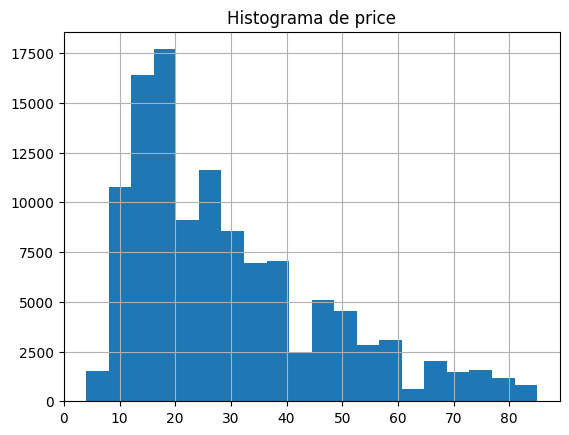

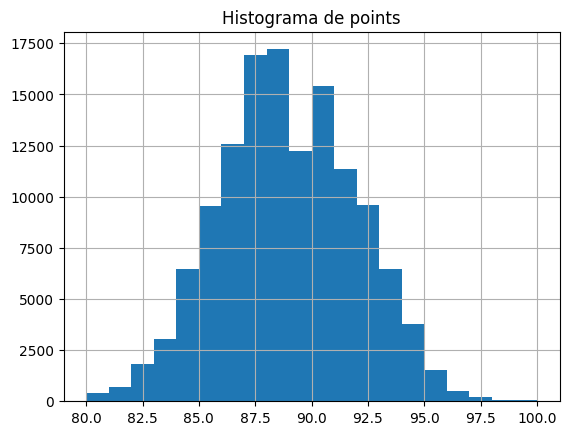

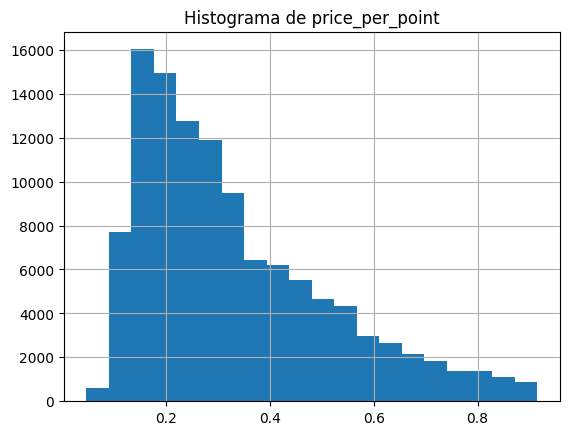

In [14]:
#Defines una lista con los nombres de 3 columnas que te interesan.
points = df['points']
prices = df[df["has_price"] == True]["price"]

price_per_point = df_filtrado["price_per_point"]
cols = [prices, points, price_per_point ]


prices_sin_outliers = np.percentile(df_filtrado['price'].dropna(), 95)
price_per_point_sin_outliers = np.percentile(df_filtrado['price_per_point'].dropna(), 95)

for c in cols:
    if c.name == "price":
        c.hist(bins=20, range=(c.min(), prices_sin_outliers))
    elif c.name == "price_per_point":
        c.hist(bins=20, range=(c.min(), price_per_point_sin_outliers))
    else:
        c.hist(bins=20)
    plt.title(f"Histograma de {c.name}")
    plt.show()

## 15. Hacer un mini análisis final.

In [15]:
#¿Qué país tiene los vinos con mayor puntuación media (points) y cuál tiene los más bajos?
media_por_pais = df.groupby("country")["points"].mean()

pais_mejor = media_por_pais.idxmax()
pais_peor = media_por_pais.idxmin()

media_mejor = media_por_pais.max()
media_peor = media_por_pais.min()
print("Pais con mayor puntuación media: " , pais_mejor , ":", media_mejor ,"puntos")
print("Pais con menor puntuación media: ", pais_peor,":", media_peor ,"puntos")

#¿Existe una relación clara entre price y points? ¿Dónde están los vinos con precio alto pero puntuación baja o con puntuación alta pero precio bajo?
correlacion = df["price"].corr(df["points"])

print("Correlación entre precio y puntos:", correlacion)
sitio= df["country"]

bajo_precio =  df["price"] < df["price"].quantile(0.10)
alta_puntuacion = df["points"] > df["points"].quantile(0.90)

alto_precio =  df["price"] > df["price"].quantile(0.90)
baja_puntuacion = df["points"] < df["points"].quantile(0.10)

caros_malas_puntuaciones = df[alto_precio & baja_puntuacion]
baratos_buenas_puntuaciones = df[bajo_precio & alta_puntuacion]


print("\nVinos con precio alto pero puntuación baja:")
print(caros_malas_puntuaciones[["country", "price", "points"]])

print("\nVinos con precio bajo pero puntuación alta:")
print(baratos_buenas_puntuaciones[["country", "price", "points"]])
#¿Qué variedad (variety) de uva presenta una puntuación media más alta? ¿Y cuál la más baja?
 
media_variety = df.groupby("variety")["points"].mean()
 
# Variedad con mayor puntuación media
variety_mejor = media_variety.idxmax()
puntuacion_mejor = media_variety.max()
 
print("\nVariedad con puntuación media más alta:")
print(variety_mejor, ":", puntuacion_mejor)
 
# Variedad con menor puntuación media
variety_peor = media_variety.idxmin()
puntuacion_peor = media_variety.min()
 
print("\nVariedad con puntuación media más baja:")
print(variety_peor, ":", puntuacion_peor)
 
#¿Qué porcentaje de vinos no tienen precio (price nulo)? ¿Cómo afecta eso al análisis y qué recomendarías hacer al respecto?
# Contar valores nulos en price
nulos_price = df["price"].isna().sum()
 
# Total de filas
total_filas = len(df)
 
# Calcular porcentaje
porcentaje_nulos = (nulos_price / total_filas) * 100
 
print("\nPorcentaje de vinos sin precio:", porcentaje_nulos, "%")
 
#¿Los vinos con descripciones más largas (review_length) reciben mejores puntuaciones o tienen mayor precio? Analízalo.
# Crear columna con la longitud de la descripción
df["review_length"] = df["description"].str.len()
 
# Calcular correlaciones
corr_points = df["review_length"].corr(df["points"])
corr_price = df["review_length"].corr(df["price"])
 
print("\nCorrelación entre longitud de reseña y puntos:", corr_points)
print("Correlación entre longitud de reseña y precio:", corr_price)
 
# Crear grupos: reseñas largas vs cortas (según la mediana)
df["long_review"] = df["review_length"] > df["review_length"].median()
 
# Comparación de medias de puntuación
print("\nMedia de puntos según la longitud de la reseña:")
puntos_por_grupo = df.groupby("long_review")["points"].mean()
print(puntos_por_grupo)
 
# Comparación de medias de precio
print("\nMedia de precio según la longitud de la reseña:")
precio_por_grupo = df.groupby("long_review")["price"].mean()
print(precio_por_grupo)

Pais con mayor puntuación media:  England : 91.58108108108108 puntos
Pais con menor puntuación media:  Peru : 83.5625 puntos
Correlación entre precio y puntos: 0.4161667418606219

Vinos con precio alto pero puntuación baja:
       country  price  points
1139        Us  100.0      84
1276        Us   70.0      84
2163        Us   85.0      84
2936        Us   75.0      84
7088        Us   75.0      82
...        ...    ...     ...
121868      Us   72.0      81
124224  France  200.0      84
127021      Us   75.0      84
127952      Us   85.0      84
127961      Us   75.0      83

[91 rows x 3 columns]

Vinos con precio bajo pero puntuación alta:
Empty DataFrame
Columns: [country, price, points]
Index: []

Variedad con puntuación media más alta:
GelberTraminer : 95.0

Variedad con puntuación media más baja:
Chancellor : 80.5

Porcentaje de vinos sin precio: 6.921544036746659 %

Correlación entre longitud de reseña y puntos: 0.5577602558815872
Correlación entre longitud de reseña y precio:

## 16. Creación de diferentes gráficos

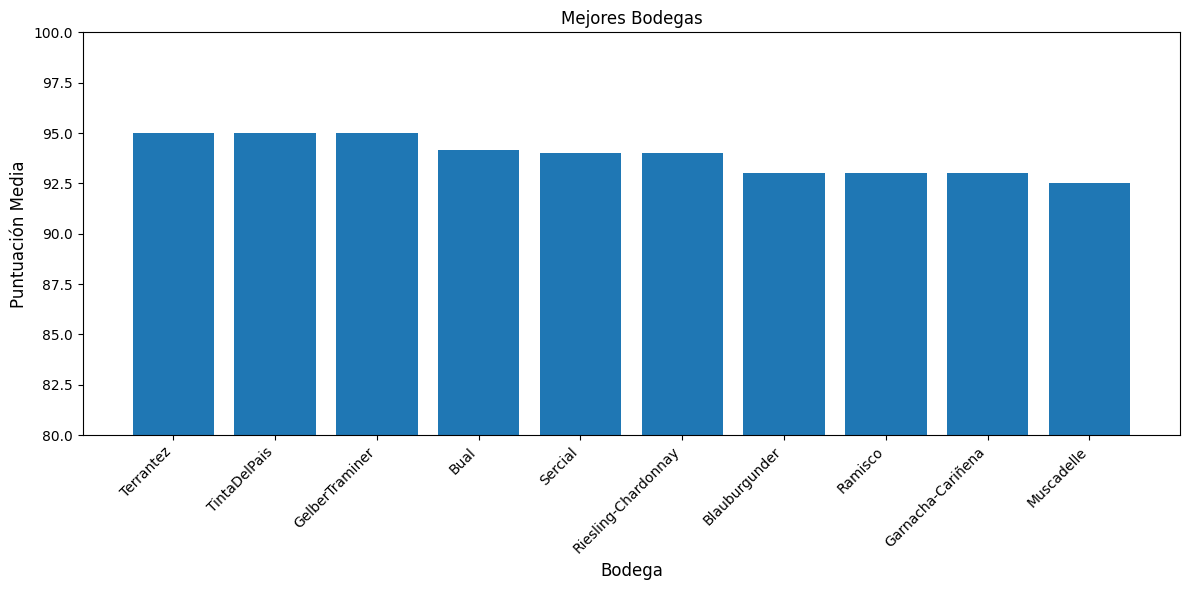

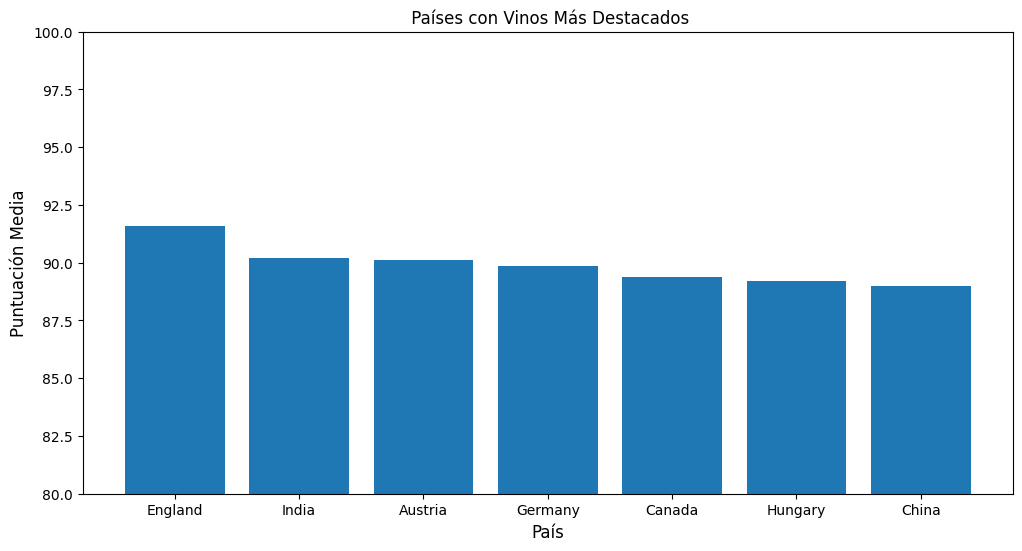

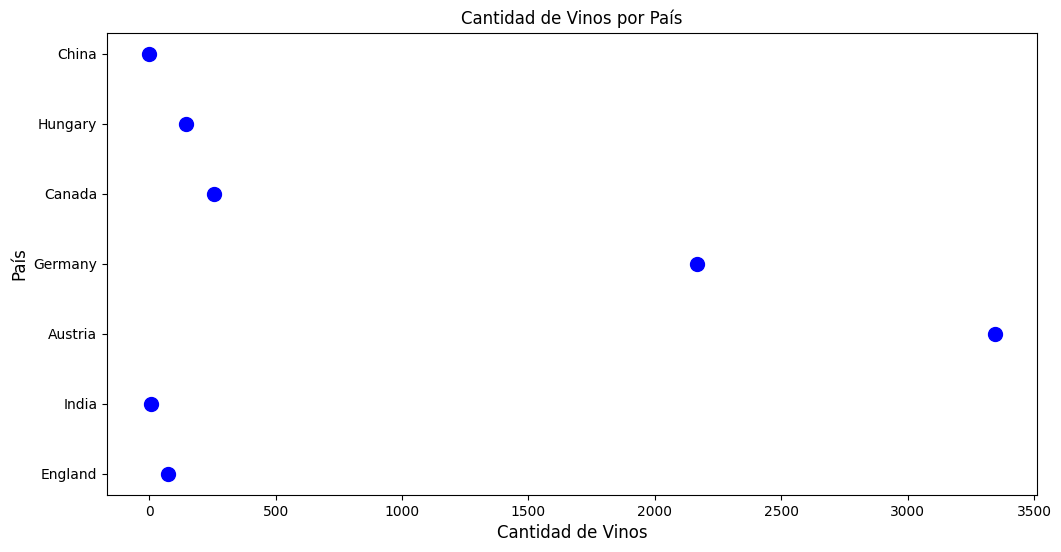

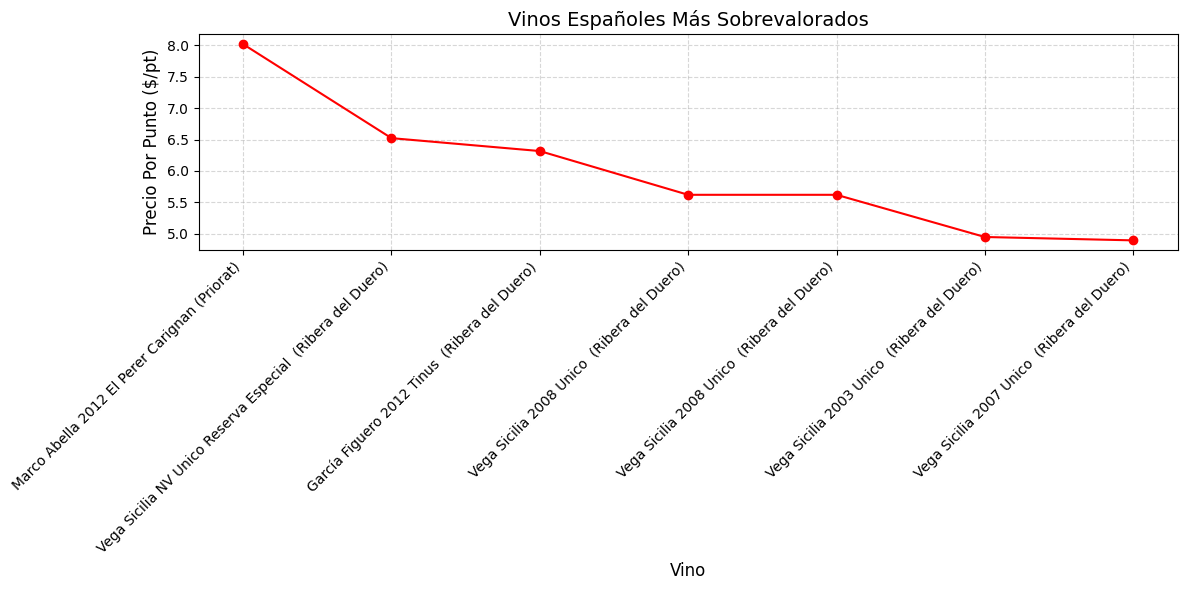

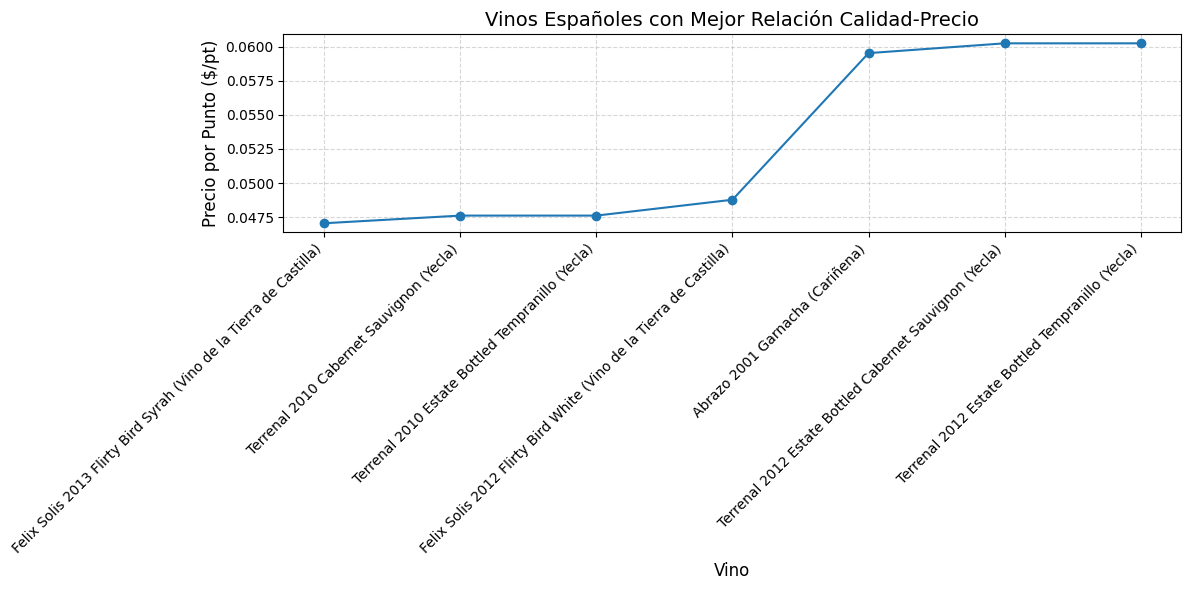

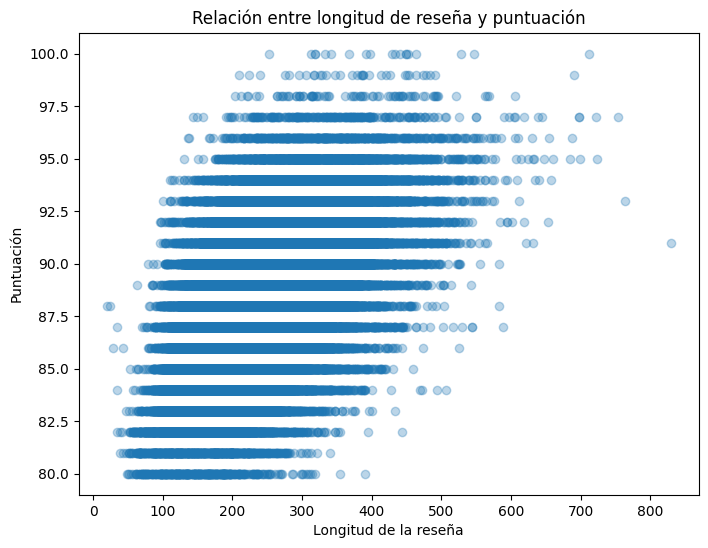

In [17]:
#GRAFICO CON MEJORES RESEÑAS
puntos_promedio_bodega = agrupacion_variety["points"].mean().sort_values(ascending=False)

# Top 10 bodegas (o variedades) por puntuación media
top10_bodegas = puntos_promedio_bodega.head(10)


# Labels y valores
labels = list(top10_bodegas.index)
heights = list(top10_bodegas.values)

#Grafico precio y puntuación
plt.figure(figsize=(12,6))
plt.title("Mejores Bodegas", fontsize=12)
plt.ylabel("Puntuación Media", fontsize=12)
plt.xlabel("Bodega", fontsize=12)

plt.ylim(80, 100)
plt.bar(labels, heights)
plt.xticks(rotation=45, ha='right')  # Para que no se encimen los nombres
plt.tight_layout()
plt.show()


# GRAFICO PAISES CON VINOS MÁS DESTACADOS
# Top 10 países por puntuación media
top7_paises_points = df.groupby('country')['points'].mean().sort_values(ascending=False).head(7)

# Listas para labels y heights
labels = list(top7_paises_points.index)
heights = list(top7_paises_points.values)

plt.figure(figsize=(12,6))
plt.title(" Países con Vinos Más Destacados", fontsize=12)
plt.ylabel("Puntuación Media", fontsize=12)
plt.xlabel("País", fontsize=12)
plt.ylim(80, 100)
plt.bar(labels, heights)
plt.show()


# Cantidad de vino por pais 
# Cantidad de vinos por país, solo top 10 de los mismos países que arriba
cantidad_vinos = df['country'].value_counts()[labels]  # mismo orden de labels

# Coordenadas
x = list(cantidad_vinos.values)
y = np.arange(len(cantidad_vinos)) 

plt.figure(figsize=(12,6))
plt.title("Cantidad de Vinos por País", fontsize=12)
plt.xlabel("Cantidad de Vinos", fontsize=12)
plt.ylabel("País", fontsize=12)
plt.scatter(x, y, marker="o", color="b", s=100)
plt.yticks(y, labels)  # mismos labels que en barras
plt.show()



#GRAFICO PAISES MENOS PUNTUACION MÁS CAROS DE ESPAÑA
# Filtrar España y datos válidos
df_es = df.dropna(subset=['price', 'points'])
df_es = df_es[df_es['country'] == 'Spain'].copy()

# Calcular price_per_point
df_es['price_per_point'] = df_es['price'] / df_es['points']

# Obtener top 7 más caros por punto
top7_sobrevalorados_es = df_es.sort_values(by='price_per_point', ascending=False).head(7)


# Listas para gráfico
x = list(range(1, len(top7_sobrevalorados_es)+1))
y = top7_sobrevalorados_es['price_per_point'].values
labels = top7_sobrevalorados_es['title'].values

plt.figure(figsize=(12,6))
plt.plot(x, y, marker='o', linestyle='-', color='red')

plt.xticks(x, labels, rotation=45, ha='right')
plt.title("Vinos Españoles Más Sobrevalorados", fontsize=14)
plt.xlabel("Vino", fontsize=12)
plt.ylabel("Precio Por Punto ($/pt)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#GRAFICO Los MAS BARATOS PERO MEJOR PUNTUACION DE ESPAÑA
# Obtener top 7 más baratos por punto (mejor calidad-precio)
top7_mejor_calidad_precio_es = df_es.sort_values(
    by='price_per_point', ascending=True
).head(7)

# Listas para gráfico
x = list(range(1, len(top7_mejor_calidad_precio_es) + 1))
y = top7_mejor_calidad_precio_es['price_per_point'].values
labels = top7_mejor_calidad_precio_es['title'].values

plt.figure(figsize=(12,6))
plt.plot(x, y, marker='o', linestyle='-')

plt.xticks(x, labels, rotation=45, ha='right')
plt.title("Vinos Españoles con Mejor Relación Calidad-Precio", fontsize=14)
plt.xlabel("Vino", fontsize=12)
plt.ylabel("Precio por Punto ($/pt)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



#GRAFICO PARA VER LA IMPORTANCIA DE LAS RESEÑAS
plt.figure(figsize=(8,6))
plt.scatter(df["review_lenght"], df["points"], alpha=0.3)

plt.xlabel("Longitud de la reseña")
plt.ylabel("Puntuación")
plt.title("Relación entre longitud de reseña y puntuación")

plt.show()


